Importando as bibliotecas iniciais

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [61]:
nasa_machine = pd.read_csv('battery_dataset/metadata.csv')

In [62]:
nasa_machine 

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7560,impedance,[2010. 9. 30. 7. 36. ...,24,B0055,247,7561,07561.csv,NaN,0.0968087979207628,0.15489738203707232
7561,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,248,7562,07562.csv,1.0201379996149256,NaN,NaN
7562,charge,[2010. 9. 30. 8. 48. 54.25],4,B0055,249,7563,07563.csv,NaN,NaN,NaN
7563,discharge,[2010. 9. 30. 11. 50. ...,4,B0055,250,7564,07564.csv,0.9907591663373165,NaN,NaN


Verificando se existem dados faltantes 

In [63]:
nasa_machine.info()

<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   type                 7565 non-null   str  
 1   start_time           7565 non-null   str  
 2   ambient_temperature  7565 non-null   int64
 3   battery_id           7565 non-null   str  
 4   test_id              7565 non-null   int64
 5   uid                  7565 non-null   int64
 6   filename             7565 non-null   str  
 7   Capacity             2794 non-null   str  
 8   Re                   1956 non-null   str  
 9   Rct                  1956 non-null   str  
dtypes: int64(3), str(7)
memory usage: 591.1 KB


In [64]:
nasa_machine.isnull().sum()

type                      0
start_time                0
ambient_temperature       0
battery_id                0
test_id                   0
uid                       0
filename                  0
Capacity               4771
Re                     5609
Rct                    5609
dtype: int64

In [65]:
nasa_machine['type'].value_counts()

type
charge       2815
discharge    2794
impedance    1956
Name: count, dtype: int64

Filtrar o DataFrame para trabalhar com a capacidade

In [66]:
df_descarga = nasa_machine[nasa_machine['type'] == 'discharge'].copy()

df_descarga.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.5080762969973425,NaN,NaN
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.4835577960067696,NaN,NaN
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.4671391666146525,NaN,NaN


Criacao de Coluna

In [67]:
# Contagem inicial sequencial de descargas por bateria, para identificar o ciclo de cada bateria
df_descarga['ciclo'] = df_descarga.groupby('battery_id').cumcount() + 1

#Exibem apenas as colunas de interesse, para facilitar a visualização
df_descarga[['battery_id', 'ciclo', 'ambient_temperature', 'Capacity']].head(10)

,battery_id,ciclo,ambient_temperature,Capacity
0,B0047,1,4,1.6743047446975208
4,B0047,2,4,1.5243662105099023
6,B0047,3,4,1.5080762969973425
8,B0047,4,4,1.4835577960067696
10,B0047,5,4,1.4671391666146525
12,B0047,6,4,1.448858156982267
16,B0047,7,4,1.4458534180949325
20,B0047,8,4,1.431118266178283
22,B0047,9,4,1.4192745516578533
24,B0047,10,4,1.3999974221808271


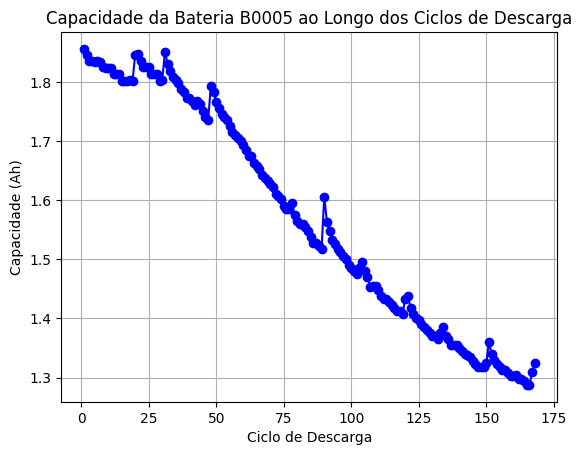

In [68]:
# Convertendo de string para float, para evitar problemas de plotagem
df_descarga['Capacity'] = pd.to_numeric(df_descarga['Capacity'], errors='coerce')
df_descarga['ambient_temperature'] = pd.to_numeric(df_descarga['ambient_temperature'], errors='coerce')
df_descarga = df_descarga.dropna(subset=['Capacity', 'ambient_temperature']).copy()


battery_exemplo = df_descarga[df_descarga['battery_id'] == 'B0005']

plt.Figure(figsize=(10, 6))
plt.plot(battery_exemplo['ciclo'], battery_exemplo['Capacity'], marker='o', linestyle='-', color='b')
plt.xlabel('Ciclo de Descarga')
plt.ylabel('Capacidade (Ah)')
plt.title('Capacidade da Bateria B0005 ao Longo dos Ciclos de Descarga')
plt.grid(True)
plt.show()


Definindo as variáveis (X) e (Y)

In [69]:
X = df_descarga[['ciclo', 'ambient_temperature']].copy()
y = df_descarga['Capacity']

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (2769, 2)
Formato de y: (2769,)



Treino e Teste

In [70]:
from sklearn.model_selection import train_test_split

In [71]:
x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

Modelo RandomForestRegressor

In [84]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [73]:
#Criando o modelo
rf_nasa = RandomForestRegressor(n_estimators=100, random_state=42)
#Treinando o modelo com os dados de treino
rf_nasa.fit(x_treino, y_treino)

previsoes = rf_nasa.predict(x_teste)

In [85]:
rf_mse = mean_squared_error(y_teste, previsoes)

rf_rmse = np.sqrt(rf_mse)


In [86]:
rf_mae = mean_absolute_error(y_teste, previsoes)
rf_r2 = r2_score(y_teste, previsoes)

print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE:  {rf_mae:.4f}")
print(f"R²:   {rf_r2:.4f}")

RMSE: 0.3397
MAE:  0.2306
R²:   0.4908


In [87]:
print(f"O erro médio (RMSE) do modelo é: {rf_rmse:.4f} Ah")

O erro médio (RMSE) do modelo é: 0.3397 Ah


Modelo - LinearRegression

In [89]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(x_treino, y_treino)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[-0. , 0.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['ciclo','ambient_temperature']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.9066
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [ ]:
alguns_dados = x_treino.iloc[:5]
algumas_labels = y_treino.iloc[:5]

print("Predicoes", lin_reg.predict(alguns_dados))
print("Labels", algumas_labels.values)

Predicoes [0.93072534 1.99556634 1.38944707 0.9670955  0.9731572 ]
labels [0.8373919  1.83285836 1.39111047 0.08289665 1.16950403]


In [91]:
from sklearn.metrics import mean_squared_error

preds = lin_reg.predict(x_treino)
lin_mse = mean_squared_error(y_treino, preds)

lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(0.3547810644612229)

In [95]:
# Fazendo as previsões nos dados de TESTE
previsoes_teste = lin_reg.predict(x_teste)

# Calculando as métricas de avaliação
mse_teste = mean_squared_error(y_teste, previsoes_teste)
rmse_teste = np.sqrt(mse_teste)
mae_teste = mean_absolute_error(y_teste, previsoes_teste)
r2_teste = r2_score(y_teste, previsoes_teste)

# Exibindo os resultados
print(f" Desempenho do LinearRegression ")
print(f"RMSE (Erro Quadrático Médio): {rmse_teste:.4f}")
print(f"MAE (Erro Absoluto Médio):    {mae_teste:.4f}")
print(f"R² (Coef. Determinação):    {r2_teste:.4f}")

 Desempenho do LinearRegression 
RMSE (Erro Quadrático Médio): 0.3693
MAE (Erro Absoluto Médio):    0.2704
R² (Coef. Determinação):    0.3983
